In [1]:
import scanpy as sc

Load in data

In [2]:
adata = sc.read_h5ad("Clint-Samuel__scANVI_annotation.h5ad")
# UMAP we need is called RNA_harmony_umap_samuel, annotation of Clint is called Clint_annotation_v2

In [3]:
adata

AnnData object with n_obs × n_vars = 137062 × 36048
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.5', 'seurat_clusters', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'RNA_snn_res.0.9', 'RNA_snn_res.1', 'RNA_snn_res.1.1', 'RNA_snn_res.1.2', 'RNA_snn_res.1.3', 'RNA_snn_res.1.4', 'RNA_snn_res.1.5', 'nCount_ADT', 'nFeature_ADT', 'sctype_classification', 'scDblFinder_class', 'scDblFinder_score', 'percent.mt', 'nCount_HTO', 'nFeature_HTO', 'MULTI_ID', 'MULTI_classification', 'barcodes', 'HTO_Results', 'DF_Results', 'HTO_GUESS', 'MULTI_ID_merge', 'LENIENT_GUESS_merge', 'Annotation_VBO', 'experiment', 'treatment', 'tech', 'ADT_snn_res.1.2', 'RNA.weight', 'ADT.weight', 'wsnn_res.1', 'celltype_new', 'Clint_annotation', 'Clint_annotation_v2', 'scanvi_predicted', 'scanvi_confidence'
    var: 'vf_vst_counts.1.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.Seur

Start with the dotplots, DEA...

In [19]:
markers = {
    "Pre_cDC1": ["Ccr2", "Fcer1g", "Vim"], # Cd24a
    "Proliferating_cDC1" :["Mki67", "Birc5", "Stmn1", "Top2a", "Mcm2", "Pcna"],
    "Early_Immature": ["Sell", "Creld2", "Pdia4"],
    "Late_Immature": ["Cd207", "Itgae", "Apol7c", "Apoe", "Cadm1", "Xcr1"], # Dnase1l3, Cd86, Cd83
    "Early_Mature": ["Cxcl10", "Cxcl9", "Iigp1", "Ifi47", "Gbp2", "Gbp5", "Cd40"],
    "Late_Mature": ["Cd63", "Fscn1", "Il4i1", "Socs2", "Ccr7"]
}

In [20]:
marker_genes_in_data = {}
for ct, markers in markers.items():
    markers_found = []
    for marker in markers:
        if marker in adata.var.index:
            markers_found.append(marker)
    marker_genes_in_data[ct] = markers_found

Calculate clusters

In [6]:
adata.obsm["X_umap"] = adata.obsm["RNA_harmony_umap_samuel"]

In [7]:
sc.pp.highly_variable_genes(adata,
                            n_top_genes=4000,
                            flavor = "seurat_v3")
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [25]:
sc.pp.neighbors(adata, use_rep="RNA_harmony_samuel", n_neighbors=15, n_pcs=30)

for res in range(1,3):
    sc.tl.leiden(adata, 
                key_added=f"leiden_{res}", 
                resolution = res,
                n_iterations=2, 
                directed=False)

Leiden clusters

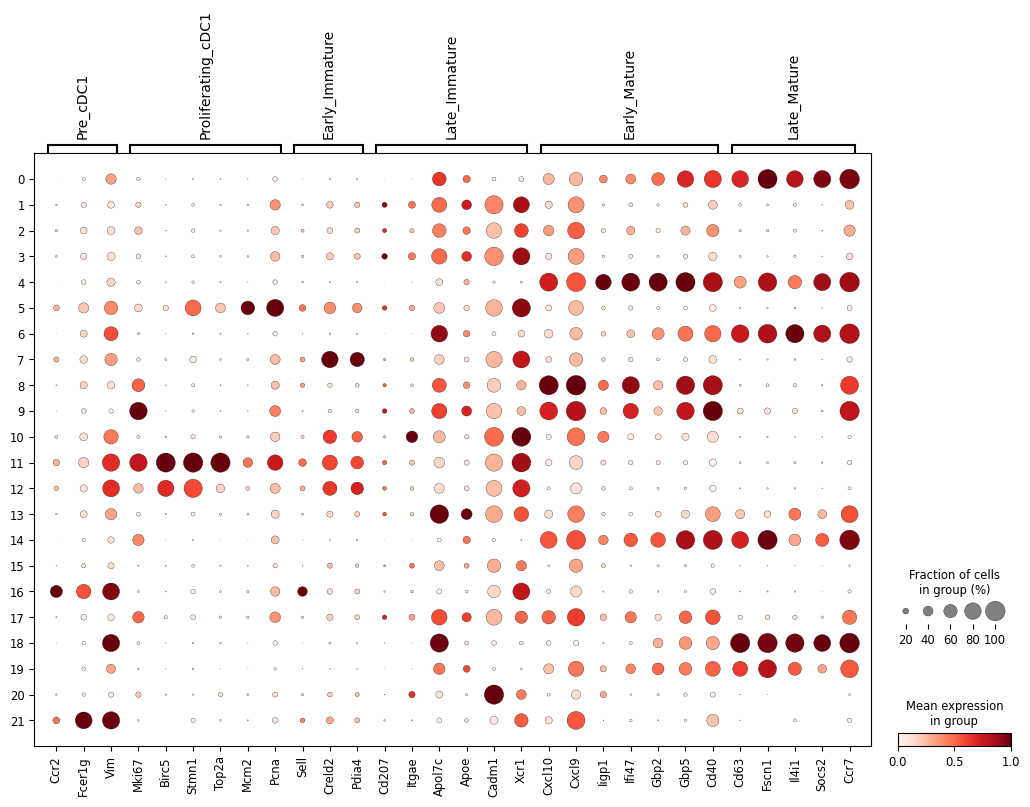

In [ ]:
sc.pl.dotplot(
    adata,
    groupby="leiden_1",
    var_names=marker_genes_in_data,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
)

Based on this dotplot:
- 0: Late_Mature
- 1: Late_Immature
- 2: Late_Immature
- 3: Late_Immature
- 4: Early_Immature
- 5: Proliferating_cDC1
- 6: Late_Mature
- 7: Early_Immature
- 8: Early_Mature
- 9: Early_Mature
- 10: Late_Immature
- 11: Proliferating_cDC1
- 12: Proliferating_cDC1
- 13: Late_Immature
- 14: Late_Mature
- 15: NA
- 16: Pre_cDC1
- 17: Late_Immature
- 18: Late_Mature
- 19: Late_Mature
- 20: NA
- 21: Pre_cDC1

In [58]:
cluster_annotations_leiden1 = {
    "0": "Late_Mature",
    "1": "Late_Immature",
    "2": "Late_Immature",
    "3": "Late_Immature",
    "4": "Late_Mature",
    "5": "Proliferating_cDC1",
    "6": "Late_Mature",
    "7": "Early_Immature",
    "8": "Early_Mature",
    "9": "Early_Mature",
    "10": "Late_Immature",
    "11": "Proliferating_cDC1",
    "12": "Proliferating_cDC1",
    "13": "Early_Mature",
    "14": "Late_Mature",
    "15": "Low_quality_Immature_cDC1",
    "16": "Pre_cDC1",
    "17": "cDC1_engulfing_RBC",
    "18": "Late_Mature",
    "19": "Late_Mature",
    "20": "Low_quality_Immature_cDC1",
    "21": "Pre_cDC1"
}

In [60]:
adata.obs["celltype_lode_manual_leiden1"] = adata.obs["leiden_1"].map(cluster_annotations_leiden1)

Explanation of cell states:
- pre-cDC1: CCR2 is associated with recently recruited DC precursors, Vim and Fc receptor expression fit an immature precursor state, but lack of strong maturation markers support pre-cDC. Other markers include: Zbtb46, Flt3, Clec9a, Xcr1, Batf3.

- Proliferating_cDC1: these are cycling cells, so proliferation markers should dominate, but should also express some cDC1 lineage specific genes to confirm their identity. 

- Early_Immature: This annotation is mainly based on absence of maturation genes.

- Late_Immature: also complicated group.

- Early_Mature: these cells have a inflammatory signature and show maturation markers

- Late_Mature: these cells express lymph node migration markers and stimulatory markers (CD86/CD40).

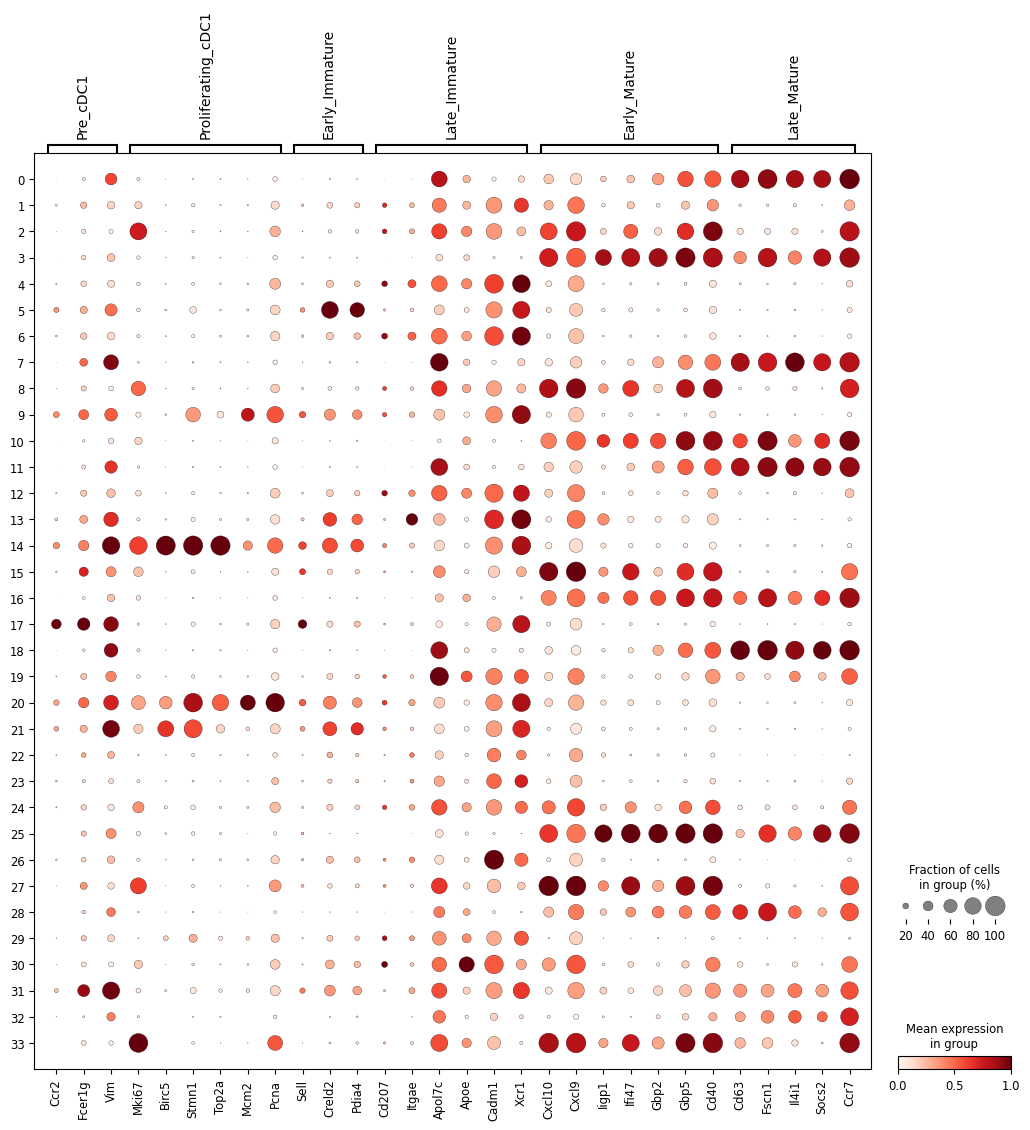

In [56]:
sc.pl.dotplot(
    adata,
    groupby="leiden_2",
    var_names=marker_genes_in_data,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
)

In [46]:
cluster_annotations_leiden2 = {
    "0": "Late_Mature",
    "1": "Late_Immature/Early_Mature",
    "2": "Late_Immature/Early_Mature",
    "3": "Early_Mature/Late_Mature",
    "4": "Late_Immature",
    "5": "Early_Immature/Late_Immature",
    "6": "Late_Immature",
    "7": "Late_Mature",
    "8": "Earlt_Mature",
    "9": "Pre_cDC1/Proliferating_cDC1/Late_Immature",
    "10": "Early_Immature/Late_Mature",
    "11": "Late_Mature",
    "12": "Late_Immature",
    "13": "Pre_cDC1/Late_Immature",
    "14": "Pre_cDC1/Proliferating_cDC1",
    "15": "Early_Mature",
    "16": "Early_Immature/Late_Mature",
    "17": "Pre_cDC1",
    "18": "Late_Mature",
    "19": "Late_Immature",
    "20": "Proliferating_cDC1",
    "21": "Pre_cDC1/Proliferating_cDC1",
    "22": "Late_Immature",
    "23": "Late_Immature",
    "24": "Late_Immature",
    "25": "Early_Mature",
    "26": "Late_Immature",
    "27": "Early_Mature",
    "28": "Early_Immature/Late_Mature",
    "29": "Late_Immature",
    "30": "Late_Immature",
    "31": "Pre_cDC1/Proliferating_cDC1",
    "32": "Late_Mature",
    "33": "Early_Mature"
}

In [47]:
adata.obs["celltype_lode_manual_leiden2"] = adata.obs["leiden_2"].map(cluster_annotations_leiden2)

In [48]:
adata

AnnData object with n_obs × n_vars = 137062 × 36048
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.5', 'seurat_clusters', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'RNA_snn_res.0.9', 'RNA_snn_res.1', 'RNA_snn_res.1.1', 'RNA_snn_res.1.2', 'RNA_snn_res.1.3', 'RNA_snn_res.1.4', 'RNA_snn_res.1.5', 'nCount_ADT', 'nFeature_ADT', 'sctype_classification', 'scDblFinder_class', 'scDblFinder_score', 'percent.mt', 'nCount_HTO', 'nFeature_HTO', 'MULTI_ID', 'MULTI_classification', 'barcodes', 'HTO_Results', 'DF_Results', 'HTO_GUESS', 'MULTI_ID_merge', 'LENIENT_GUESS_merge', 'Annotation_VBO', 'experiment', 'treatment', 'tech', 'ADT_snn_res.1.2', 'RNA.weight', 'ADT.weight', 'wsnn_res.1', 'celltype_new', 'Clint_annotation', 'Clint_annotation_v2', 'scanvi_predicted', 'scanvi_confidence', 'leiden_1', 'leiden_2', 'celltype_lode_manual_leiden1', 'celltype_lode_manual_leiden2'
    var: 'vf_vst_counts.1.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.

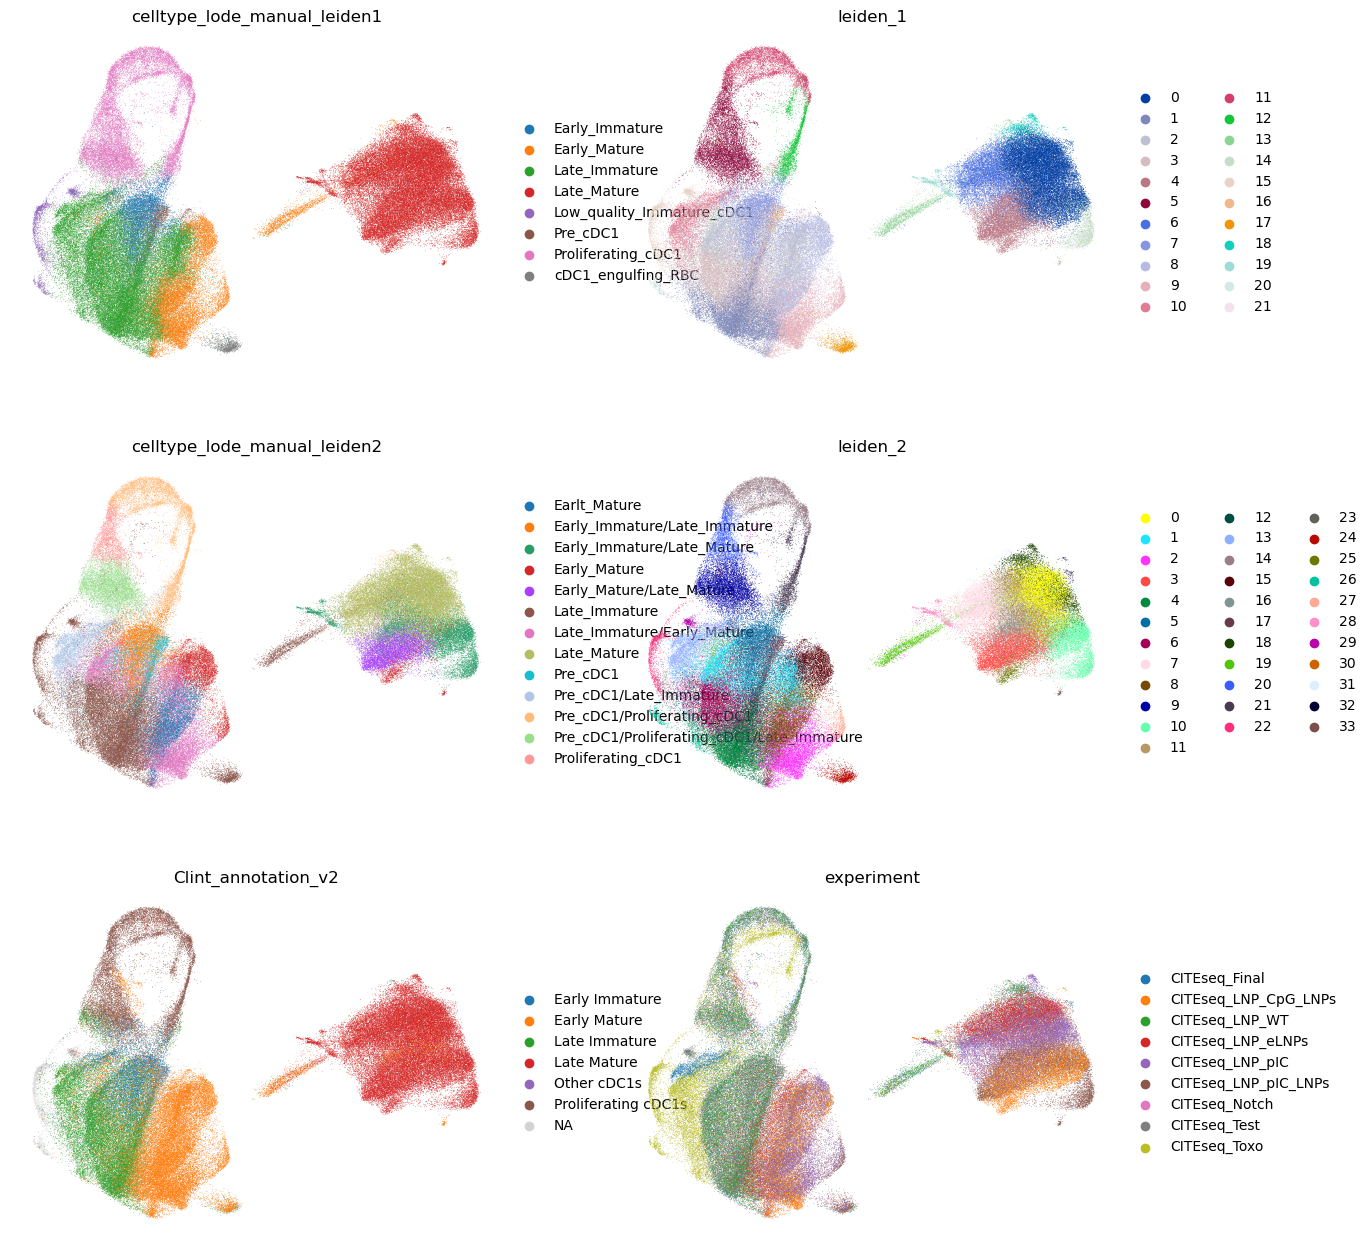

In [61]:
sc.pl.umap(adata,
           color=["celltype_lode_manual_leiden1", "leiden_1", "celltype_lode_manual_leiden2", "leiden_2", "Clint_annotation_v2", "experiment"],
           frameon=False,
           legend_loc = "right margin",
           ncols=2)

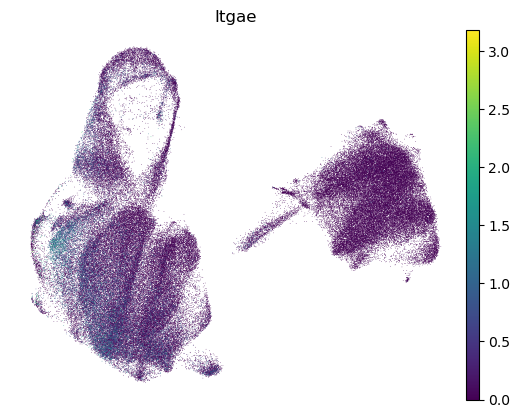

In [ ]:
sc.pl.umap(adata,
           color=["Itgae"],
           frameon=False,
           legend_loc = "right margin",
           ncols=1)

Plotting the clusters

Perform DEA

In [10]:
sc.tl.rank_genes_groups(
    adata, groupby="leiden_1", method="wilcoxon", key_added="dea_leiden_1"
)

c:\Users\irc\miniconda3\envs\tv\lib\site-packages\scanpy\tools\_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
c:\Users\irc\miniconda3\envs\tv\lib\site-packages\scanpy\tools\_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
c:\Users\irc\miniconda3\envs\tv\lib\site-packages\scanpy\tools\_rank_genes_groups.py:463: PerformanceWarning: DataFrame is highly fragmente

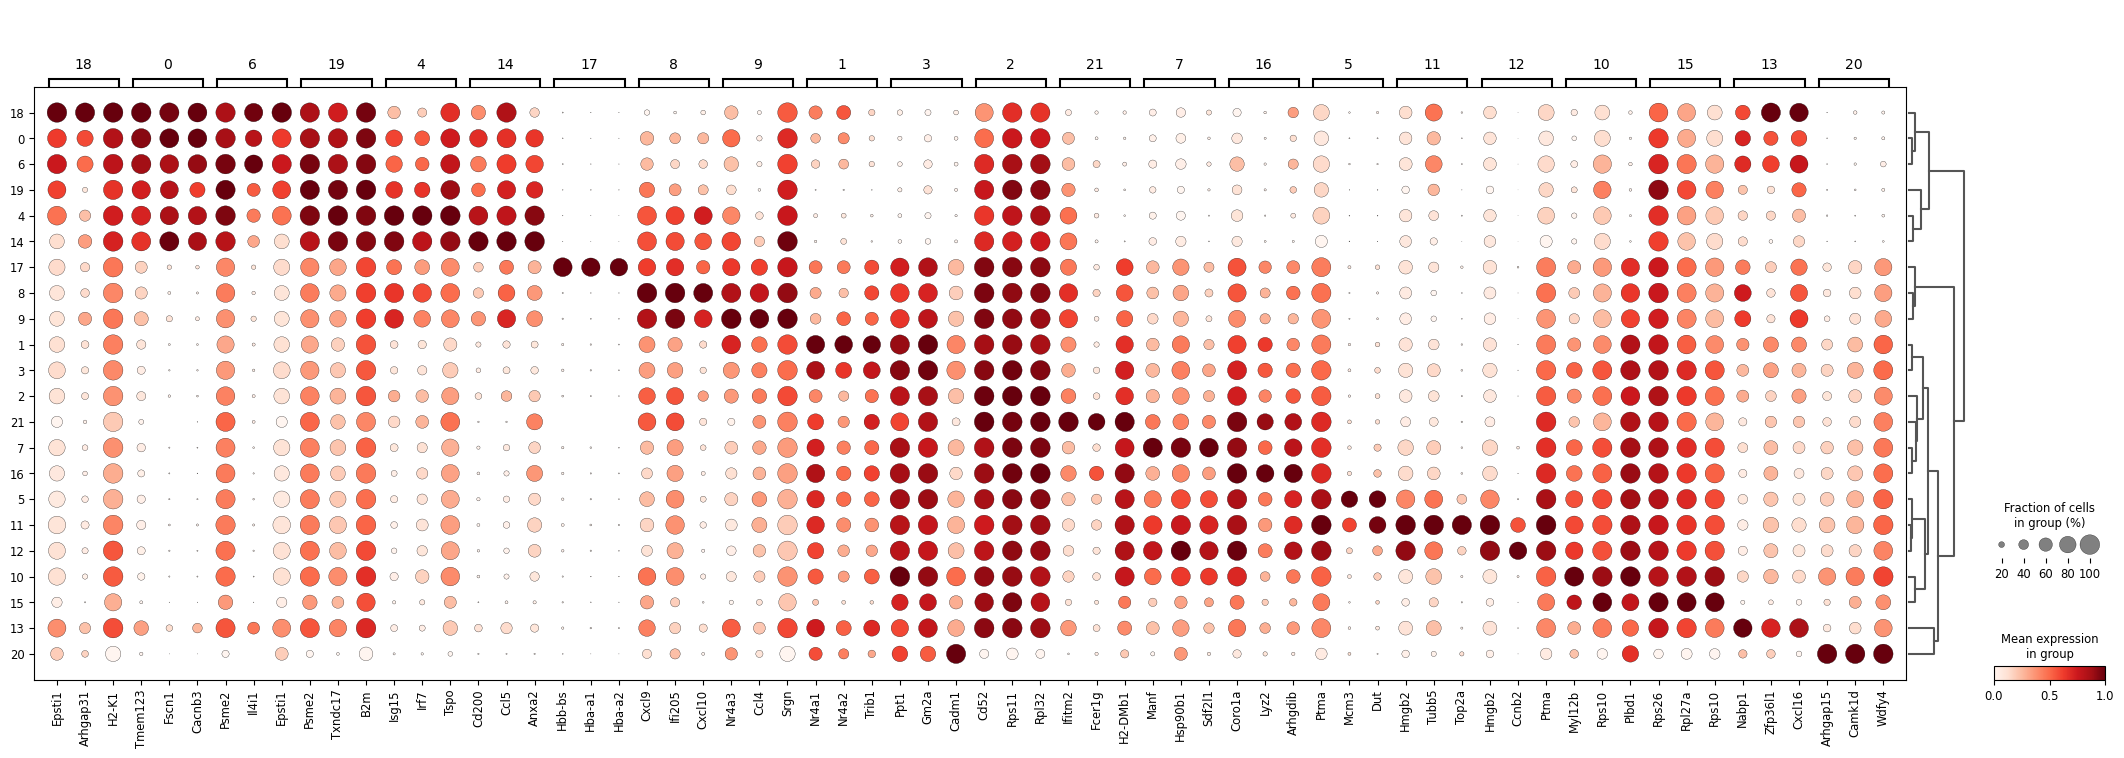

In [ ]:
sc.tl.dendrogram(
    adata,
    groupby="leiden_1",
)

sc.pl.rank_genes_groups_dotplot(
    adata, groupby="leiden_1", standard_scale="var", n_genes=3, key="dea_leiden_1"
)

# 17 have eaten RBC

Now, we will transfer the following annotations to Clint's original annotation:
- Proliferating cDCs1
- RBC engulfing cDC1s
- Low quality cells
- Give his remaining NA cells a label

In [71]:
adata.obs["Clint_annotation_v2"].value_counts(dropna=False)

Clint_annotation_v2
Late Mature            46693
Early Mature           36059
Late Immature          26598
Proliferating cDC1s    14285
Early Immature          9375
NaN                     3986
Other cDC1s               66
Name: count, dtype: int64

In [72]:
adata.obs["celltype_lode_manual_leiden1"].value_counts(dropna=False)

celltype_lode_manual_leiden1
Late_Mature                  46305
Late_Immature                42379
Early_Mature                 18447
Proliferating_cDC1           16595
Early_Immature                8287
Low_quality_Immature_cDC1     2065
Pre_cDC1                      1755
cDC1_engulfing_RBC            1229
Name: count, dtype: int64

In [80]:
# copy all annotations from the Clint column, and then copy the specific annotations from the other .obs 

# Convert both annotations to strings (avoids categorical restrictions)
clint = adata.obs["Clint_annotation_v2"].astype(object)
leiden = adata.obs["celltype_lode_manual_leiden1"].astype(object)

# Start with Clint annotation
adata.obs["celltype_final_2026"] = clint

# Fill missing Clint annotations with Leiden annotations
mask_nan = adata.obs["celltype_final_2026"].isna()
adata.obs.loc[mask_nan, "celltype_final_2026"] = leiden[mask_nan]

# Replace specific categories using Leiden annotations
replace_annotations = [
    "Proliferating_cDC1",
    "Low_quality_Immature_cDC1",
    "Pre_cDC1",
    "cDC1_engulfing_RBC"
]

mask_replace = leiden.isin(replace_annotations)
adata.obs.loc[mask_replace, "celltype_final_2026"] = leiden[mask_replace]

# Fix spelling inconsistency
adata.obs["celltype_final_2026"] = adata.obs["celltype_final_2026"].replace({
    "Proliferating cDC1s": "Proliferating_cDC1"
})

# Convert back to categorical for Scanpy
adata.obs["celltype_final_2026"] = (
    adata.obs["celltype_final_2026"].astype("category")
)

In [82]:
# fix up inconsistent labelling

adata.obs["celltype_final_2026"] = adata.obs["celltype_final_2026"].replace({
    "Late_Immature": "Late Immature",
    "Late_Mature": "Late Mature",
    "Early_Immature": "Early Immature",
    "Early_Mature": "Early Mature",
})

C:\Users\irc\AppData\Local\Temp\ipykernel_19396\3835424895.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs["celltype_final_2026"] = adata.obs["celltype_final_2026"].replace({


In [83]:
adata.obs["celltype_final_2026"].value_counts()

celltype_final_2026
Late Mature                  46658
Early Mature                 34173
Late Immature                26195
Proliferating_cDC1           17433
Early Immature                7498
Low_quality_Immature_cDC1     2065
Pre_cDC1                      1755
cDC1_engulfing_RBC            1229
Other cDC1s                     56
Name: count, dtype: int64

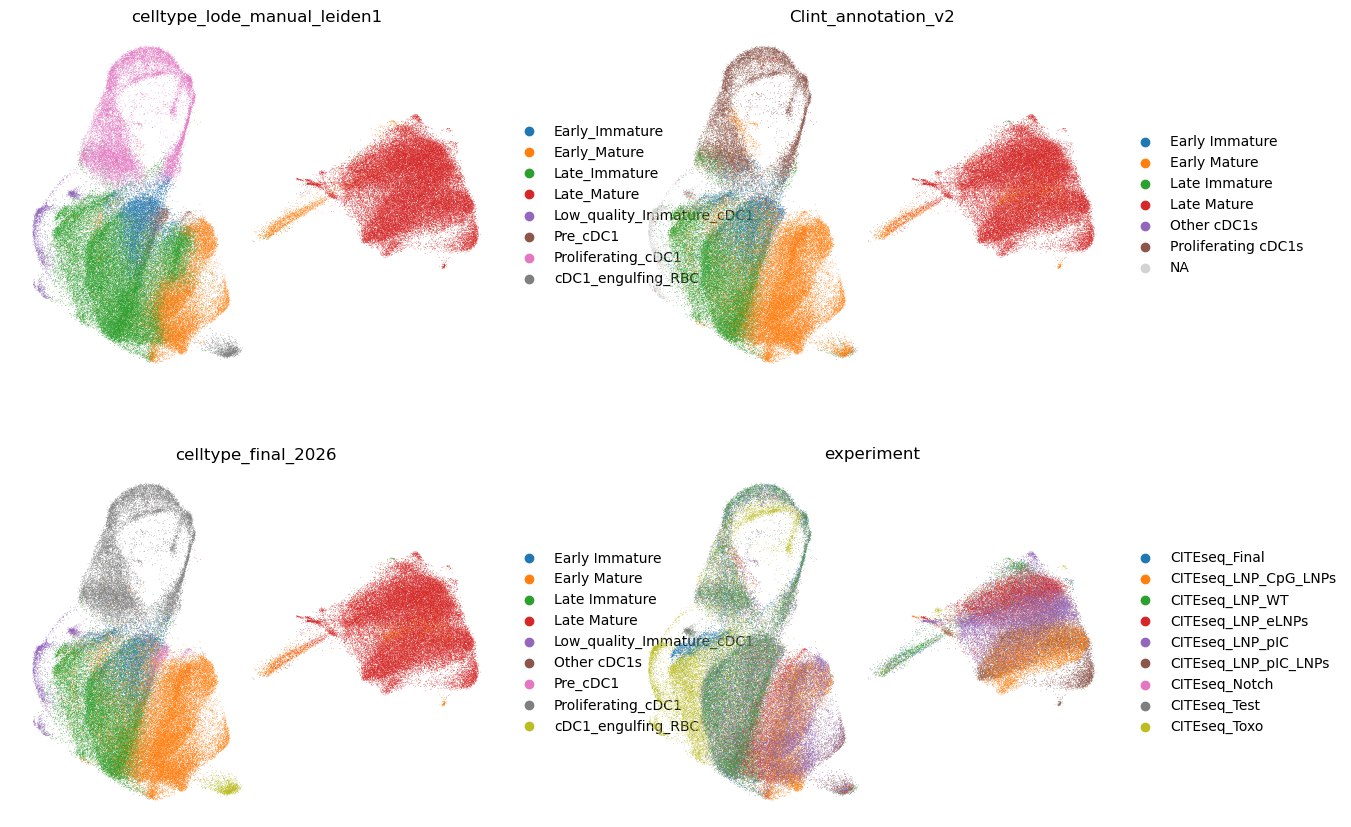

In [84]:
sc.pl.umap(adata,
           color=["celltype_lode_manual_leiden1", "Clint_annotation_v2", "celltype_final_2026", "experiment"],
           frameon=False,
           legend_loc = "right margin",
           ncols=2)

The annotation is now fixed

In [ ]:
# write out
adata.write("final_annotation_2026.h5ad")
